# 불꽃 미탐 분석 — 기존 YOLO11n 모델 사용
**재학습하지 않습니다. MP4도 사용하지 않습니다.** validation 3,445장의 정답 fire 박스와 예측을 비교합니다. 낮은 confidence 기준으로 불꽃을 더 찾을 때 늘어나는 오탐도 함께 계산합니다.

Colab에서 GPU 런타임을 선택하고 위에서 아래로 실행하세요. 기존 학습 노트북을 다시 돌릴 필요는 없습니다. 런타임이 바뀌면 이 노트북의 데이터 준비 셀이 자동으로 학습용 사본을 다시 만듭니다. ZIP·학습 모델·기존 test/val 결과는 수정하지 않습니다.

test는 이미 확인했으므로 기존 모델의 기준 결과로 보관하세요. 개선 설정은 val로 선택하고, 개선 모델의 최종 성능 주장은 새 미사용 자료로 확인하는 것이 좋습니다.

In [1]:
from google.colab import drive
drive.mount('/content/drive')
from pathlib import Path
DRIVE_ROOT = Path('/content/drive/MyDrive/2026 3학년 2학기 진로탐색')
SHARED_PROJECT = DRIVE_ROOT / 'Code' / 'fire-ai'
DFIRE = DRIVE_ROOT / 'Data' / 'DFire'
ACTIVE_RUN = DFIRE / 'training_results' / 'yolo11n_v1' / 'jongwon_to70_20261004T144737Z_9154ce3d'
EXPECTED_MODEL_SHA256 = '57c133a489976dc2f7341381b12cf160622e0bbaff33aeffdee4926e2093611d'
LOCAL_DATASET = Path('/content/fire-ai-data-v2')
LOCAL_ANALYSIS = Path('/content/fire-fn-analysis')
for path in (SHARED_PROJECT / 'scripts' / 'analyze_fire_misses.py', ACTIVE_RUN / 'final' / 'best.pt'):
    assert path.is_file(), f'공유 폴더/모델 경로를 확인하세요: {path}'
print('분석할 학습 실행:', ACTIVE_RUN)

Mounted at /content/drive
분석할 학습 실행: /content/drive/MyDrive/2026 3학년 2학기 진로탐색/Data/DFire/training_results/yolo11n_v1/jongwon_to70_20261004T144737Z_9154ce3d


## 1. 분석 코드와 패키지 준비
Colab의 CUDA용 PyTorch는 그대로 사용합니다. 설치 후 런타임 재시작 안내가 나오면 재시작하고 처음부터 다시 실행하세요.

In [2]:
import shutil, subprocess, sys, uuid, importlib
PROJECT_DIR = Path('/content') / ('fire-fn-code-' + uuid.uuid4().hex[:8])
shutil.copytree(SHARED_PROJECT / 'scripts', PROJECT_DIR / 'scripts', ignore=shutil.ignore_patterns('__pycache__'))
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', '-r', str(SHARED_PROJECT / 'requirements-colab.txt')], check=True)
sys.path.insert(0, str(PROJECT_DIR / 'scripts'))
for name in ('training_workflow', 'prepare_dfire', 'analyze_fire_misses'):
    sys.modules.pop(name, None)
importlib.invalidate_caches()
from training_workflow import copy_verified, sha256, read_json, runtime_info
from analyze_fire_misses import analyze
print(runtime_info())
assert runtime_info()['gpu'], '런타임 유형을 GPU로 변경하세요.'
assert sha256(ACTIVE_RUN / 'final' / 'best.pt') == EXPECTED_MODEL_SHA256, '선정 모델이 다른 파일입니다.'

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.
{'python': '3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]', 'platform': 'Linux-6.6.122+-x86_64-with-glibc2.39', 'torch': '2.11.0+cu130', 'ultralytics': '8.4.143', 'cuda': '13.0', 'gpu': 'Tesla T4'}


## 2. 데이터 준비 — 원본 ZIP 변경 없음
이미 준비된 현재 런타임의 데이터가 있으면 재사용합니다. 새 런타임에서는 ZIP을 /content로 복사해 공식 fold 1과 기존 라벨 정리 정책을 적용합니다. 대용량 데이터는 Drive로 다시 저장하지 않습니다.

In [3]:
if (LOCAL_DATASET / 'dataset_summary.json').is_file():
    print('기존 Colab 데이터 재사용:', LOCAL_DATASET)
else:
    LOCAL_ARCHIVES = Path('/content/dfire-archives-v2')
    LOCAL_ARCHIVES.mkdir(exist_ok=True)
    for filename in ('D-Fire.zip', 'd-fire 텍스트 분할.zip'):
        source, target = DFIRE / filename, LOCAL_ARCHIVES / filename
        if not target.is_file() or sha256(target) != sha256(source):
            print('Colab 로컬로 복사:', filename, flush=True)
            copy_verified(source, target)
    subprocess.run([sys.executable, str(PROJECT_DIR / 'scripts' / 'prepare_dfire.py'),
        '--dataset-zip', str(LOCAL_ARCHIVES / 'D-Fire.zip'),
        '--split-zip', str(LOCAL_ARCHIVES / 'd-fire 텍스트 분할.zip'),
        '--output', str(LOCAL_DATASET), '--fold', '1', '--verify-images'], check=True)
print(read_json(LOCAL_DATASET / 'dataset_summary.json')['splits'])
# 분석 직전에 현재 라벨/분할/원본 해시와 학습 당시 메타데이터를 다시 비교합니다.

Colab 로컬로 복사: D-Fire.zip
Colab 로컬로 복사: d-fire 텍스트 분할.zip
{'train': {'images': 13776, 'labels': 13776, 'boxes': 17307, 'negative_images': 6223}, 'val': {'images': 3445, 'labels': 3445, 'boxes': 4043, 'negative_images': 1610}, 'test': {'images': 4306, 'labels': 4306, 'boxes': 5189, 'negative_images': 2005}}


## 3. 불꽃 미탐 추출과 confidence 비교
이 셀은 GPU **추론만** 실행합니다. confidence 0.05부터 후보를 수집하고 0.10/0.15/0.20/0.25/0.35/0.50에서 비교합니다. 불꽃 정답과 fire 예측 박스가 IoU 0.5 이상으로 일대일 매칭되면 검출로 봅니다.

이것은 고정 confidence의 오류 분석입니다. 기존 val 출력의 recall이나 mAP와 계산 조건이 달라 숫자가 같을 필요가 없습니다. 오탐도 확인하려고 fire가 없는 이미지까지 전체 val을 처리합니다.

결과는 선택한 학습 실행의 analysis/새고유폴더에 저장합니다. 이미지 예시는 최대 30장이고, 모델이나 전체 데이터는 Drive에 중복 저장하지 않습니다. GPU 메모리 부족이면 BATCH_ANALYSIS=8로 바꾸고 이 셀을 다시 실행하세요.

In [4]:
BATCH_ANALYSIS = 16
ANALYSIS_DIR = analyze(ACTIVE_RUN, LOCAL_DATASET, LOCAL_ANALYSIS,
    device='0', batch=BATCH_ANALYSIS, max_examples=30,
    expected_model_sha256=EXPECTED_MODEL_SHA256)
print('Drive 저장 완료:', ANALYSIS_DIR)

Validation images: 200/3445
Validation images: 400/3445
Validation images: 600/3445
Validation images: 800/3445
Validation images: 1000/3445
Validation images: 1200/3445
Validation images: 1400/3445
Validation images: 1600/3445
Validation images: 1800/3445
Validation images: 2000/3445
Validation images: 2200/3445
Validation images: 2400/3445
Validation images: 2600/3445
Validation images: 2800/3445
Validation images: 3000/3445
Validation images: 3200/3445
Validation images: 3400/3445
Completed 3445 images. Report saved: /content/drive/MyDrive/2026 3학년 2학기 진로탐색/Data/DFire/training_results/yolo11n_v1/jongwon_to70_20261004T144737Z_9154ce3d/analysis/fire_fn_val_20261004T151828Z_23484307
Drive 저장 완료: /content/drive/MyDrive/2026 3학년 2학기 진로탐색/Data/DFire/training_results/yolo11n_v1/jongwon_to70_20261004T144737Z_9154ce3d/analysis/fire_fn_val_20261004T151828Z_23484307


## 4. 표와 미탐 사진 확인
빨강=놓친 불꽃 정답, 초록=매칭된 불꽃 정답, 파랑=fire 예측, 노랑=smoke 예측. 예측 박스는 conf 0.25 이상만 그림에 표시합니다.

threshold_sweep 표의 fn이 줄어드는지뿐 아니라 fp와 no_fire_images_with_fire_fp도 보세요. 기준을 낮추면 더 많이 잡을 수도 있지만 정상 장면에서 화재라고 잘못 판단할 수도 있습니다. 자동으로 기준을 바꾸지는 않습니다.

hint는 사람이 검토할 단서이지 원인 확정이 아닙니다. low_confidence_candidate=낮은 점수로 후보가 있음, smoke_overlap_review=연기 예측과 겹침(실제 연기/불꽃 겹침일 수도 있음), localization_or_weak_overlap=박스 위치 검토, no_overlapping_fire_at_conf005=conf 0.05에서도 겹치는 fire 후보가 없음.

validation 이미지: 3445
불꽃 정답 박스: 2154
conf 0.25에서 놓친 불꽃 박스: 640
미탐이 하나 이상 있는 이미지: 354
검토 힌트별 개수: {'no_overlapping_fire_at_conf005': 58, 'low_confidence_candidate': 315, 'localization_or_weak_overlap': 255, 'smoke_overlap_review': 12}


,confidence,tp,fp,fn,fire_images_missed_all,images_with_fire_fp,no_fire_images_with_fire_fp,precision,recall
0,0.10,1741,2360,413,60,699,69,0.424531,0.808264
1,0.15,1650,1639,504,75,615,51,0.501672,0.766017
2,0.20,1576,1166,578,85,538,41,0.574763,0.731662
3,0.25,1514,870,640,96,475,34,0.635067,0.702878
4,0.35,1377,498,777,126,349,23,0.734400,0.639276
5,0.50,1060,205,1094,223,165,7,0.837945,0.492108


,file_name,gt_index,x1,y1,x2,y2,area_fraction,hint,aligned_fire_score,best_fire_iou,best_smoke_iou
0,AoF04024.jpg,4,836.0,291.0,853.0,315.0,0.000443,no_overlapping_fire_at_conf005,NaN,0.000000,0.001506
1,AoF04040.jpg,5,479.0,262.0,535.0,311.0,0.002977,low_confidence_candidate,0.111408,0.644877,0.013603
2,AoF04163.jpg,2,687.0,270.0,719.0,306.0,0.001250,low_confidence_candidate,0.175547,0.723926,0.044426
3,AoF04266.jpg,1,481.0,355.0,553.0,424.0,0.005391,localization_or_weak_overlap,NaN,0.461009,0.000000
4,AoF04295.jpg,1,711.0,337.0,737.0,372.0,0.000987,no_overlapping_fire_at_conf005,NaN,0.000000,0.021416
5,AoF04416.jpg,0,45.0,353.0,76.0,379.0,0.000875,localization_or_weak_overlap,NaN,0.314112,0.041811
6,AoF04431.jpg,2,545.0,216.0,584.0,241.0,0.004047,low_confidence_candidate,0.229397,0.748691,0.004259
7,AoF04431.jpg,3,597.0,198.0,656.0,242.0,0.010776,low_confidence_candidate,0.114983,0.548285,0.011340
8,AoF04432.jpg,1,309.0,180.0,452.0,205.0,0.014729,localization_or_weak_overlap,NaN,0.360236,0.023204
9,AoF04432.jpg,3,461.0,191.0,475.0,204.0,0.000750,low_confidence_candidate,0.096371,0.593056,0.001181


AoF04266.jpg


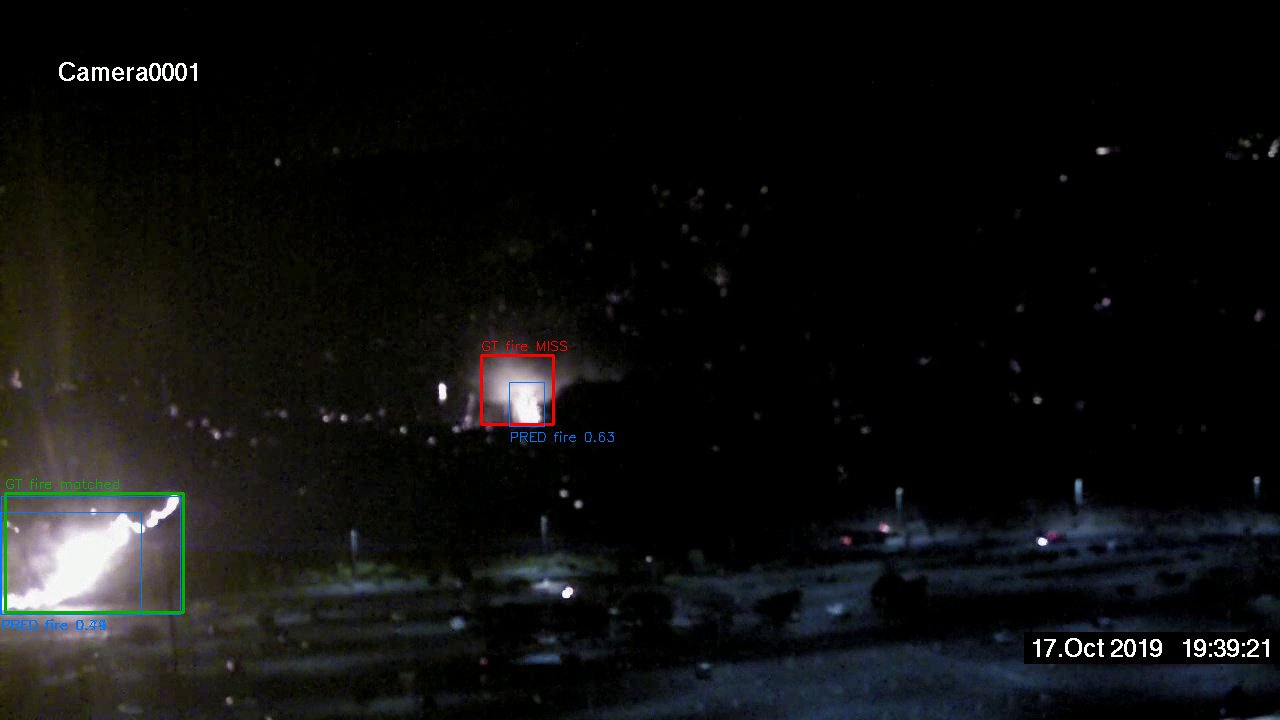

AoF04519.jpg


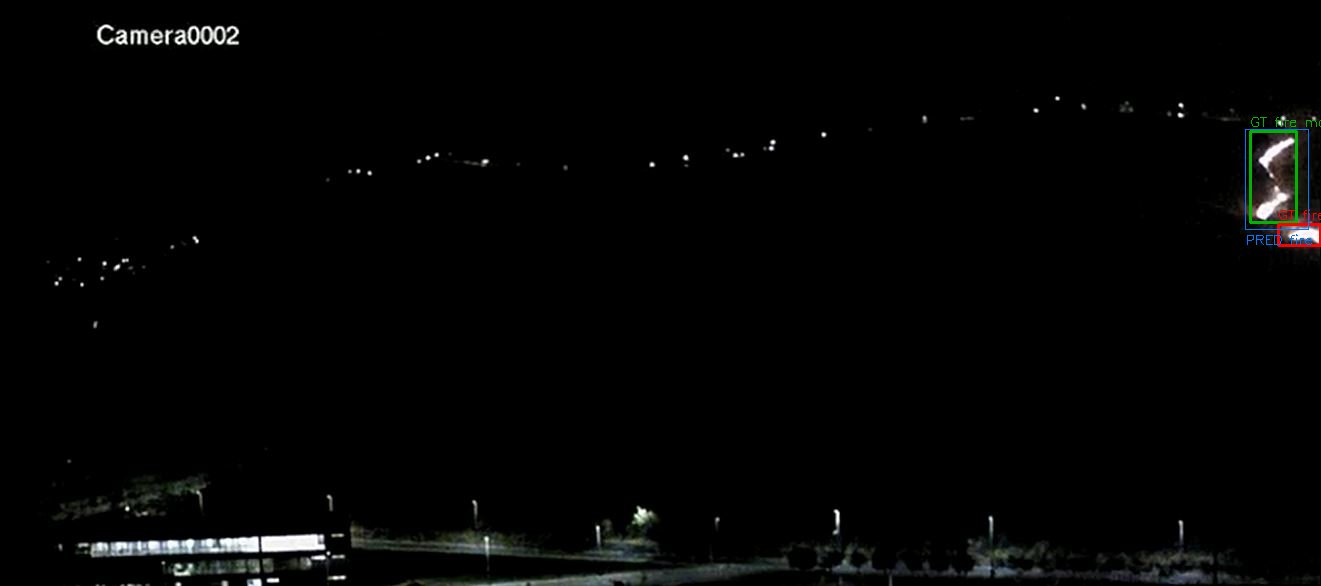

AoF04568.jpg


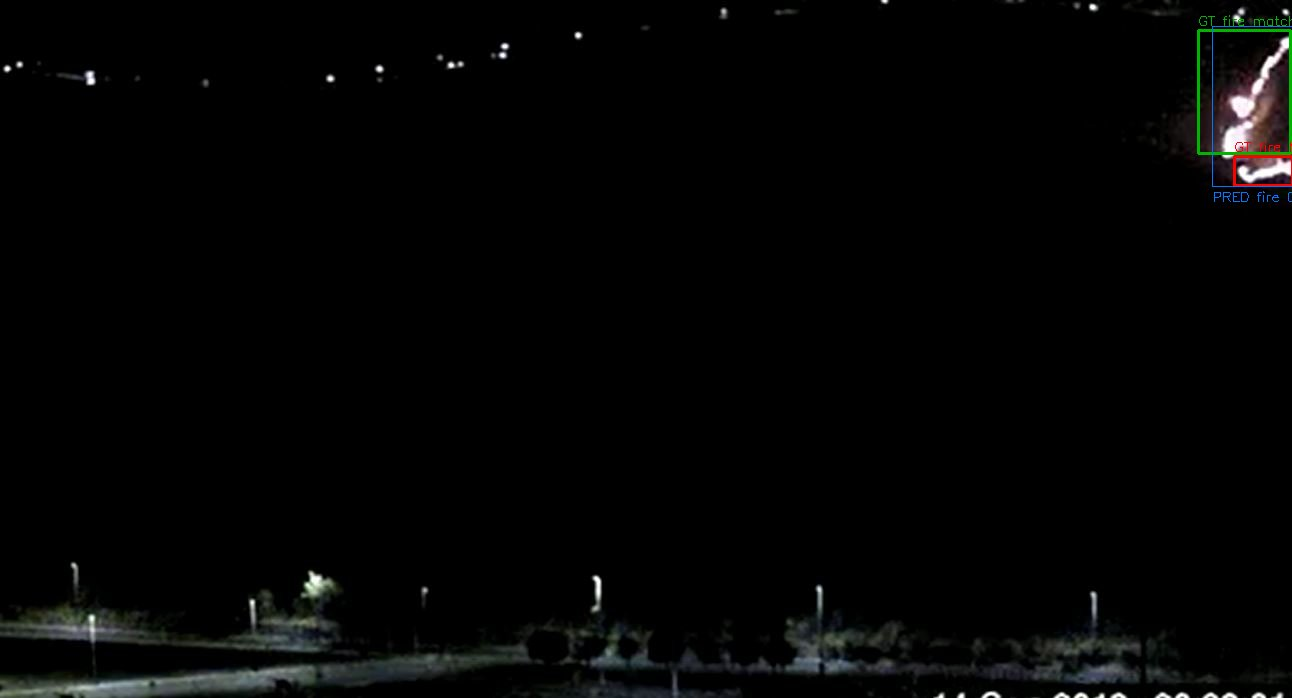

AoF04925.jpg


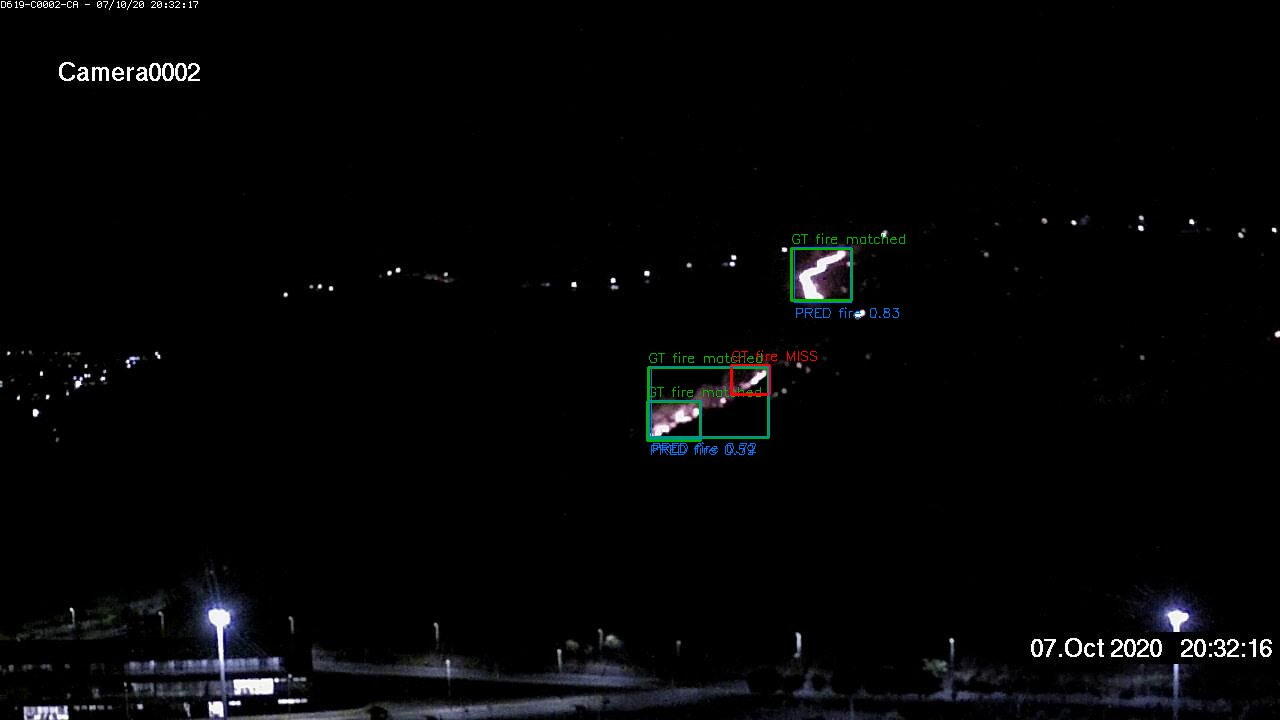

AoF04974.jpg


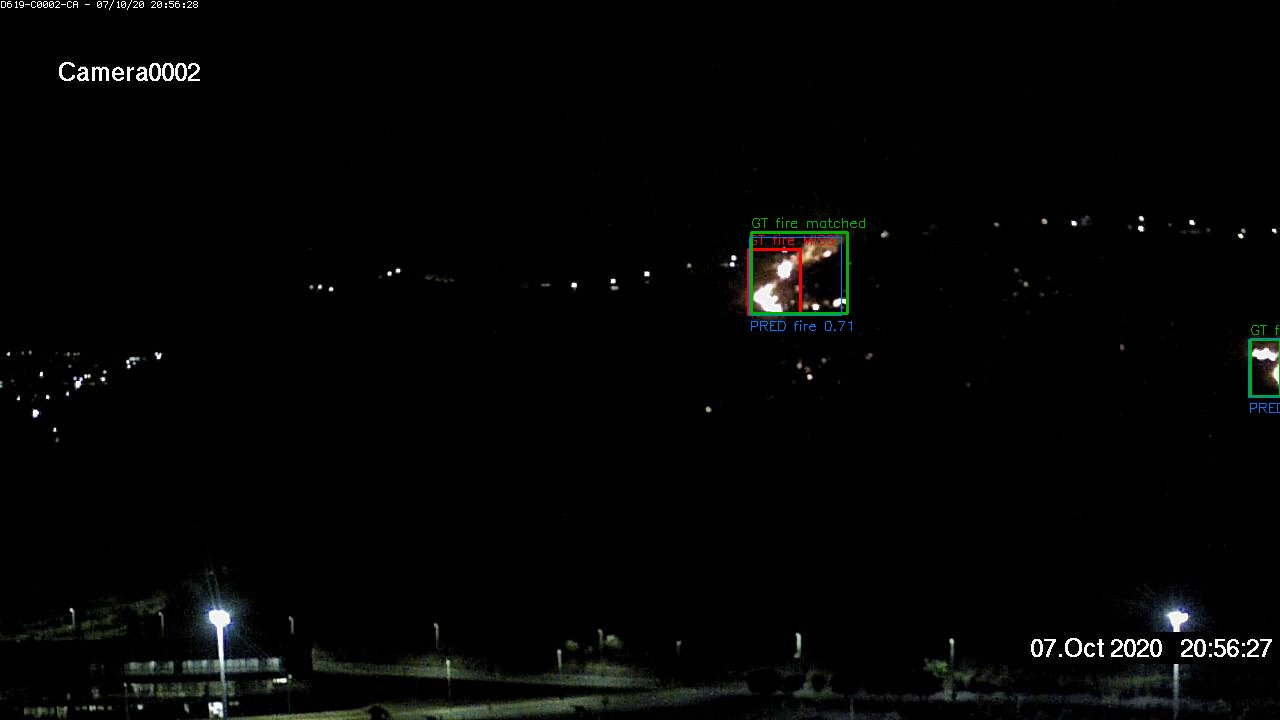

WEB03735.jpg


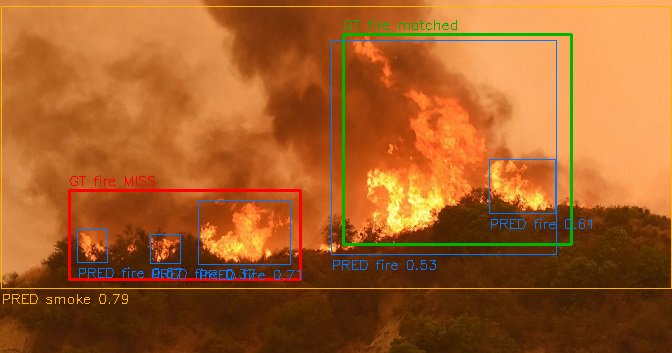

WEB03769.jpg


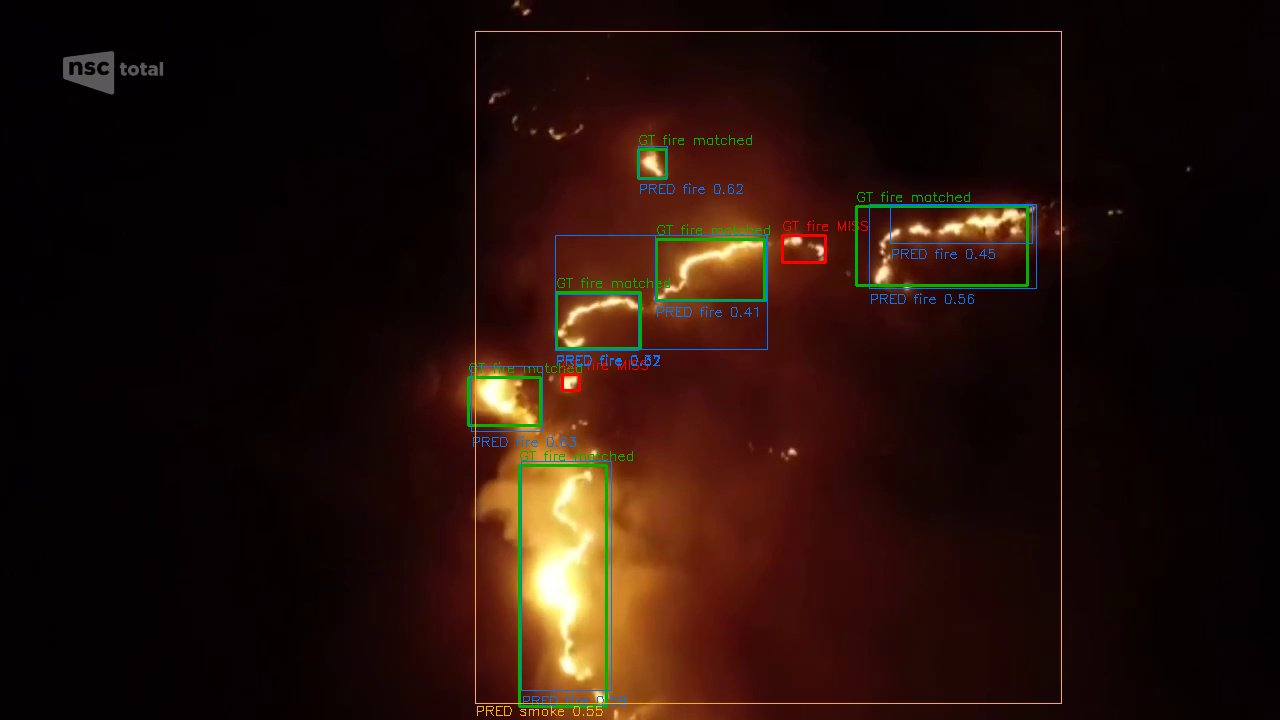

WEB03795.jpg


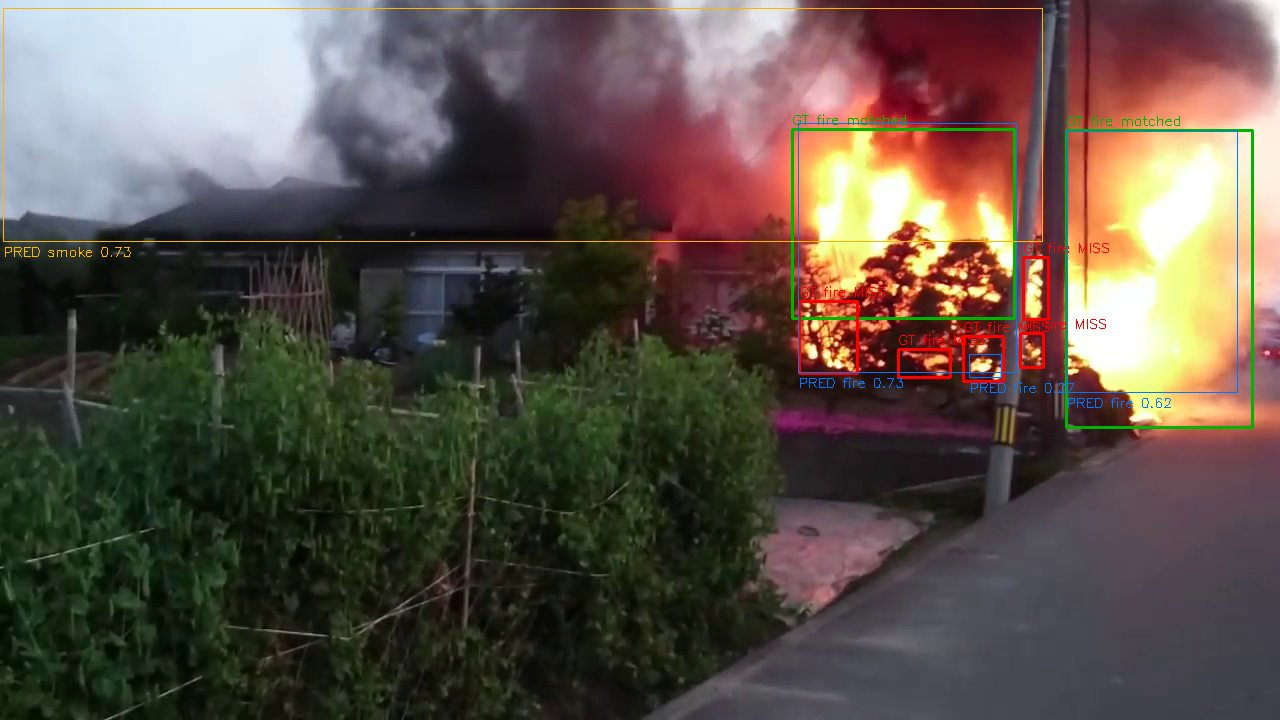

WEB03869.jpg


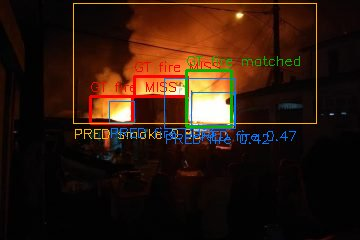

WEB04018.jpg


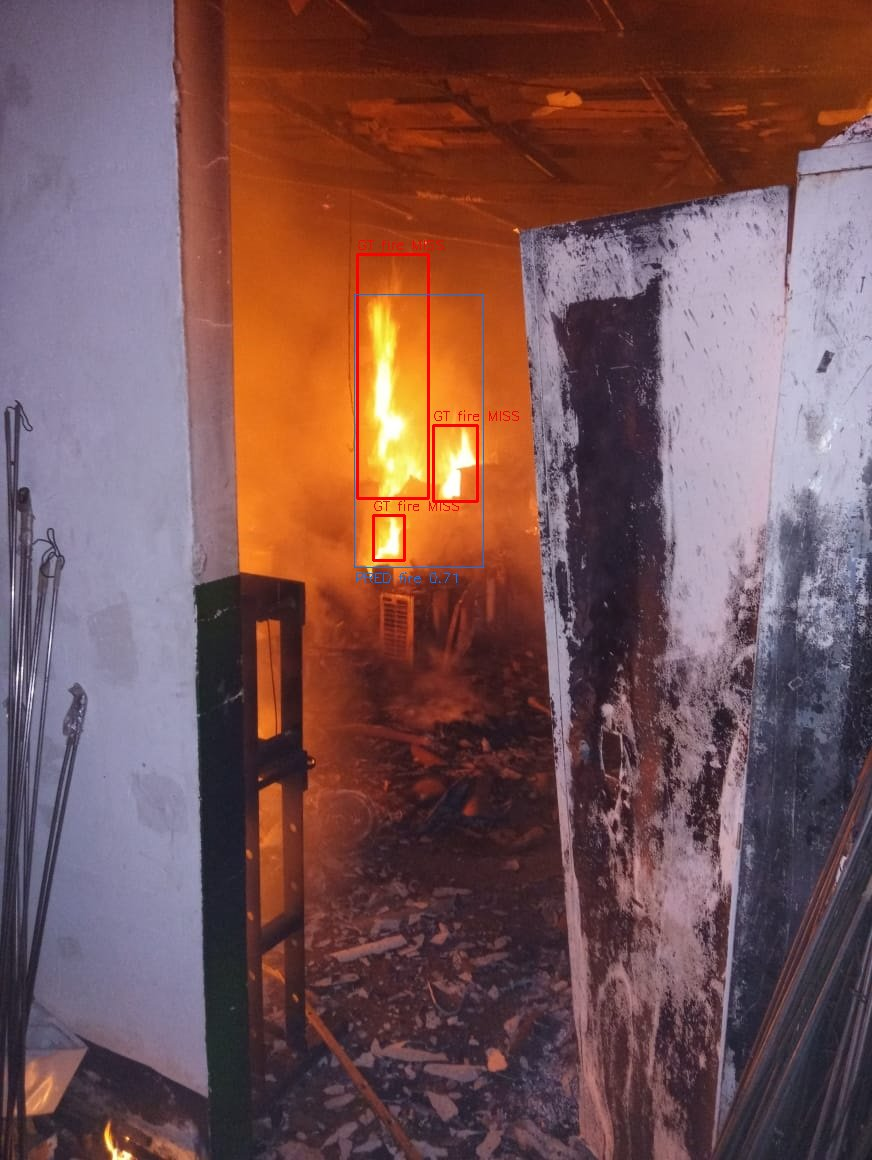

WEB04376.jpg


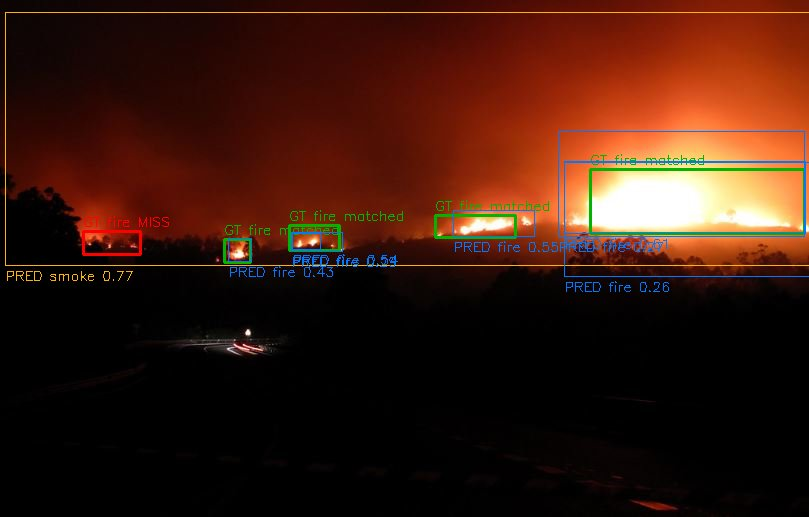

WEB04479.jpg


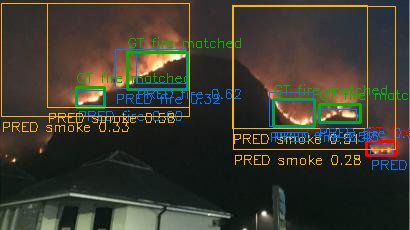

In [5]:
import pandas as pd
from IPython.display import display, Image
report = read_json(ANALYSIS_DIR / 'summary.json')
print('validation 이미지:', report['images'])
print('불꽃 정답 박스:', report['gt_fire_boxes'])
print('conf 0.25에서 놓친 불꽃 박스:', report['baseline_missed_boxes'])
print('미탐이 하나 이상 있는 이미지:', report['baseline_missed_images'])
print('검토 힌트별 개수:', report['hint_counts'])
display(pd.read_csv(ANALYSIS_DIR / 'threshold_sweep.csv'))
display(pd.read_csv(ANALYSIS_DIR / 'fire_missed_boxes.csv').head(20))
for image_path in sorted((ANALYSIS_DIR / 'examples').glob('*.jpg'))[:12]:
    print(image_path.name)
    display(Image(filename=str(image_path), width=800))

## 이후 개선 순서
1. 위 confidence 표와 빨간 미탐 사진을 공유하고 원인을 분류합니다(작은 불꽃·야간·가림·박스 위치·라벨 검토 등).
2. 낮은 confidence가 미탐을 줄이고 오탐 증가가 허용 가능한지 val로 판단합니다. test 결과를 기준으로 고르지 않습니다.
3. 기준 조정으로 해결되지 않는 사례는 train 쪽 유사 사례의 라벨 QA/추가 데이터를 검토하고 새 실험으로 학습합니다. val/test 이미지를 train에 넣지 않습니다.
4. 원인별 조치 후 같은 val 조건에서 기준 모델과 비교합니다. 새 모델의 최종 검증에는 새 미사용 자료가 필요합니다.

이 노트북은 API 연결·사건 확정·시간 필터·재학습을 하지 않습니다. 이미지 기반 미탐 분석 단계입니다.